In [152]:
# DEPENDENCIAS
import pandas as pd
import numpy as np
import os
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import emoji
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import re
from collections import Counter
from langdetect import detect
from deep_translator import GoogleTranslator
import time
import logging
import pandas as pd

# Opciones de visualización de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [153]:
# CARGA DE ARCHIVOS

# URL DATA: Lectura del excel principal de la extracción de datos
try:
    df = pd.read_excel(os.path.join('data', 'url_data.xlsx'))
    print("Archivo Excel leído correctamente")
except FileNotFoundError:
    print("Error: No se encontró el archivo 'url_data.xlsx'")
    print("Asegúrate de que el archivo está en el mismo directorio que este notebook")
    raise
except Exception as e:
    print(f"Error al leer el archivo Excel: {e}")
    raise


Archivo Excel leído correctamente


#### Análisis Descriptivo-Exploratorio y ETL:

##### URL Data

In [ ]:
print("\nDimensiones del dataset:", df.shape)


Dimensiones del dataset: (214, 9)


In [154]:
print("\nPrimeras filas:")
print("-----------------")
df.head(3)


Primeras filas:
-----------------


,url_video,transcription,tiktok_username,followers_count,video_likes,video_description,extraction_error,publish_date,video_views
0,https://www.tiktok.com/@aliciarev/video/728025...,¿Qué cuánto cuesta mi rutina de skincare de n...,aliciarev,1400000,61200,¿cuánto cuesta mi rutina de skincare de noche?...,NaN,2023-09-18,573000
1,https://www.tiktok.com/@cintia.makeuupp/video/...,Mi maquillaje diario Lo primero que haría ser...,cintia.makeuupp,244100,46000,Me lo habéis pedido mucho 💗🫶🏻 #maquillajediari...,NaN,2022-09-27,970100
2,https://www.tiktok.com/@carmensantaellaar/vide...,el precio de mi maquillaje diario es realment...,carmensantaellaar,447800,11500,Cuánto vale mi rutina de maquillaje? Spoiler: ...,NaN,2024-10-30,212100


In [150]:
print("\nInformación del dataset:")
print("------------------------")
print(df.info())


Información del dataset:
------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   url_video          214 non-null    object 
 1   transcription      214 non-null    object 
 2   tiktok_username    214 non-null    object 
 3   followers_count    214 non-null    int64  
 4   video_likes        214 non-null    int64  
 5   video_description  214 non-null    object 
 6   extraction_error   0 non-null      float64
 7   publish_date       214 non-null    object 
 8   video_views        214 non-null    int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 15.2+ KB
None


In [151]:
# CAMBIOS DE TIPOS DE DATOS: 

# A fecha:
df['publish_date'] = pd.to_datetime(df['publish_date'])

# Cols de texto que están como objects a String:
columnas_texto = ['transcription', 'tiktok_username', 'video_description', 'url_video']
for columna in columnas_texto:
    df[columna] = df[columna].astype('string')
print("Nuevos tipos de datos:")
print("----------------------")
print(df.dtypes)

Nuevos tipos de datos:
----------------------
url_video            string[python]
transcription        string[python]
tiktok_username      string[python]
followers_count               int64
video_likes                   int64
video_description    string[python]
extraction_error            float64
publish_date         datetime64[ns]
video_views                   int64
dtype: object


In [116]:
# RENOMBRAR COLUMNAS: 

# url_video a id_urlvideo, porque es un id
df.columns.values[0] = 'id_urlvideo'

In [ ]:
print("\nEstadísticas descriptivas:")
print("----------------------------")
print(df.describe())


Estadísticas descriptivas:
----------------------------
       followers_count    video_likes  extraction_error  \
count     2.140000e+02     214.000000               0.0   
mean      5.502941e+05   52048.490654               NaN   
min       7.200000e+01     111.000000               NaN   
25%       5.930000e+04    5367.750000               NaN   
50%       2.546995e+05   19000.000000               NaN   
75%       4.835750e+05   57700.000000               NaN   
max       1.010000e+07  933200.000000               NaN   
std       1.072579e+06  102951.014658               NaN   

                        publish_date   video_views  
count                            214  2.140000e+02  
mean   2024-04-25 00:47:06.168224256  5.466199e+05  
min              2020-09-03 00:00:00  1.542000e+03  
25%              2023-12-05 06:00:00  7.940000e+04  
50%              2024-06-09 12:00:00  2.552000e+05  
75%              2024-11-05 18:00:00  6.064000e+05  
max              2025-01-28 00:00:00  5.

In [131]:
# GESTIÓN DE VALORES NULOS: 

print("\nValores nulos por columna:")
print("----------------------------")
print(df.isnull().sum())

# Quito la columna de extraction error porque solo tiene valores nulos y no es relevante
# La columna recogía si habia un error al extraer los datos el tipo de error, al estar vacía no sirve de nada, es que ha sacado los datos bien
del df['extraction_error']

print("\nValores nulos por columna tras eliminar extraction_error:")
print("-----------------------------------------------------------")
print(df.isnull().sum())


Valores nulos por columna:
----------------------------
id_urlvideo            0
transcription          0
tiktok_username        0
followers_count        0
video_likes            0
video_description      0
extraction_error     203
publish_date           0
video_views            0
dtype: int64

Valores nulos por columna tras eliminar extraction_error:
-----------------------------------------------------------
id_urlvideo          0
transcription        0
tiktok_username      0
followers_count      0
video_likes          0
video_description    0
publish_date         0
video_views          0
dtype: int64


In [ ]:
# GESTIÓN DE COLUMNAS

## Limpieza de la descripción del video: separación de los tags del video que aparecen en la descripción del mismo para tenerlos a parte y separación de emojis. 

def split_description_hashtags(text):
    '''Separar texto de descripción de texto con hastagash (tags)'''
    words = text.split()
    hashtags = ' '.join([word for word in words if word.startswith('#')])
    description = ' '.join([word for word in words if not word.startswith('#')])
    return description, hashtags

def clean_hashtags(hashtags):
    '''Limpieza de #, separación de los tags por espacios y concatenamos con , '''
    if isinstance(hashtags, str):
        # Dividimos por espacios, eliminamos el # y unimos con comas
        cleaned = ', '.join(tag.replace('#', '').strip() for tag in hashtags.split())
        return cleaned
    return ''
# Creación de columnas nuevas: 
df['video_description'], df['description_hashtags'] = zip(*df['video_description'].apply(split_description_hashtags))
df['cleaned_tags'] = df['description_hashtags'].apply(clean_hashtags)

# Para no tener columnas repetitivas, quitamos la columna de description hastags y mantenemos solo la de los tags limpios, renombrandola: 
df = df.drop('description_hashtags', axis=1)
df = df.rename(columns={'cleaned_tags': 'video_description_tags'})

# Para dejar más limpio el texto de la descripción del video, separamos los emojis que contiene en una columna a parte: 
def split_text_and_emojis(text):
    '''Función para separar los emojis del texto de descripción con la libreria de emoji'''
    emojis = ''.join(c for c in text if c in emoji.EMOJI_DATA)
    clean_text = emoji.replace_emoji(text, '').strip()
    clean_text = ' '.join(clean_text.split())
    return clean_text, emojis

# Aplicamos función al df:
df['video_description'], df['description_emojis'] = zip(*df['video_description'].apply(split_text_and_emojis))
df[['video_description', 'description_emojis', 'video_description_tags']].head()


C:\Users\sandr\AppData\Local\Temp\ipykernel_8812\2490786239.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['video_description'], df['description_hashtags'] = zip(*df['video_description'].apply(split_description_hashtags))
C:\Users\sandr\AppData\Local\Temp\ipykernel_8812\2490786239.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['video_description'], df['description_hashtags'] = zip(*df['video_description'].apply(split_description_hashtags))
C:\Users\sandr\AppData\Local\Temp\ipykernel_8812\2

,video_description,description_emojis,video_description_tags
0,How much does my night skincare routine cost?,🧖♀🌙💸,
1,You've asked me a lot,💗🫶🏻,"dailymakeup, stepbystep, makeup, makeuproutine..."
2,How much is my makeup routine worth? Spoiler: ...,🫠,"makeup, tutorial, skincare, luxury, tricks"
5,Makeup that I would always buy again all time ...,💗✨,"makeupfavs, repurchasingmakeup, repurchasing, ..."
6,A very natural look :))),,makeuptutorial


In [ ]:
# Verificación de tipos de datos de las columnas nuevas y/o modificadas: 
print("Tipos de datos actuales:")
print(df[['video_description', 'description_emojis', 'video_description_tags']].dtypes)

# Conversión a string: 
df['video_description'] = df['video_description'].astype('string')
df['description_emojis'] = df['description_emojis'].astype('string')
df['video_description_tags'] = df['video_description_tags'].astype('string')

print("\nTipos de datos después de la conversión:")
print(df[['video_description', 'description_emojis', 'video_description_tags']].dtypes)

Tipos de datos actuales:
video_description         object
description_emojis        object
video_description_tags    object
dtype: object

Tipos de datos después de la conversión:
video_description         string[python]
description_emojis        string[python]
video_description_tags    string[python]
dtype: object



Distribución de idiomas:
original_video_language
Spanish    174
English     40
Name: count, dtype: Int64


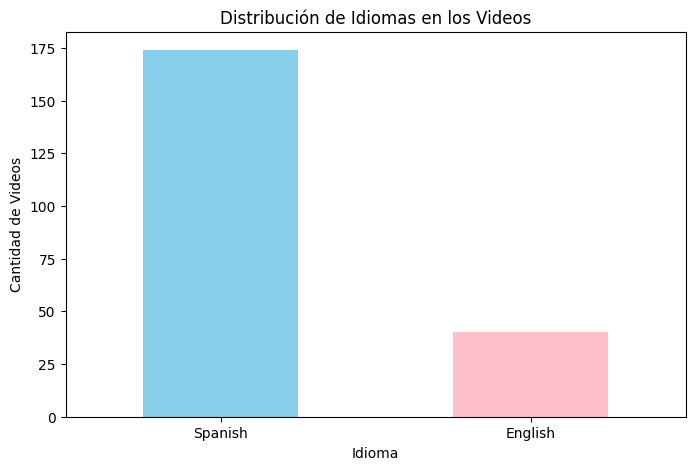

In [ ]:
# NUEVA COLUMNA: detectar si el video es en inglés o en español con la librería langdetect

def detectar_idioma(texto):
    try:
        # Si el texto es NaN o vacío, devuelve 'Unknown'
        if pd.isna(texto) or texto == '':
            return 'Unknown'
        idioma = detect(str(texto))
        if idioma == 'es':
            return 'Spanish'
        elif idioma == 'en':
            return 'English'
        else:
            return 'Other'
    except:
        return 'Unknown'

df['original_video_language'] = df['transcription'].apply(detectar_idioma).astype('string')

print("\nDistribución de idiomas:")
print(df['original_video_language'].value_counts())

# Gráfica de barras:
plt.figure(figsize=(8, 5))
df['original_video_language'].value_counts().plot(kind='bar', color=['skyblue', 'pink', 'green'])
plt.title('Distribución de Idiomas en los Videos')
plt.xlabel('Idioma')
plt.ylabel('Cantidad de Videos')
plt.xticks(rotation=0)
plt.show()


In [ ]:
# UNIFICACIÓN DE IDIOMA

def translate_text(text: str) -> str:
    try:
        if not text or str(text).strip() == '':
            return ''
        
        max_length = 4500
        if len(str(text)) <= max_length:
            return GoogleTranslator(source='auto', target='en').translate(str(text))
        chunks = [str(text)[i:i + max_length] for i in range(0, len(str(text)), max_length)]
        translated_chunks = []
        
        for chunk in chunks:
            translated = GoogleTranslator(source='auto', target='en').translate(chunk)
            translated_chunks.append(translated)
            time.sleep(1)
        return ' '.join(translated_chunks)
    except Exception as e:
        logging.error(f"Translation error for text: {e}")
        return text

def translate_with_retry(text: str, max_retries: int = 3) -> str:
    for attempt in range(max_retries):
        try:
            translated = translate_text(text)
            return translated
        except Exception as e:
            if attempt == max_retries - 1:
                logging.error(f"Failed to translate after {max_retries} attempts: {e}")
                return text
            time.sleep(2 ** attempt)

def translate_non_english_content(df: pd.DataFrame):
    total_rows = len(df)
    
    for index, row in df.iterrows():
        if str(row['original_video_language']).strip() != 'English':
            logging.info(f"Processing row {index + 1}/{total_rows}")
            
            # Traducir descripción
            if pd.notna(row['video_description']) and row['video_description'] != '':
                translated_desc = translate_with_retry(row['video_description'])
                df.at[index, 'video_description'] = translated_desc
                
            # Traducir transcripción (nombre correcto de la columna)
            if pd.notna(row['transcription']) and row['transcription'] != '':
                translated_trans = translate_with_retry(row['transcription'])
                df.at[index, 'transcription'] = translated_trans
            
            time.sleep(1)
        else:
            logging.info(f"Skipping row {index + 1}/{total_rows} (already in English)")

try:
    logging.basicConfig(
        level=logging.INFO,
        format='%(asctime)s - %(levelname)s - %(message)s'
    )
    
    # Contar cuántas filas no están en inglés
    non_english_count = df[df['original_video_language'] != 'English'].shape[0]
    logging.info(f"Found {non_english_count} rows in non-English languages")
    
    if non_english_count > 0:
        logging.info("Starting translation process...")
        translate_non_english_content(df)
        logging.info("Translation process completed successfully")
    else:
        logging.info("No translation needed - all content is already in English")
    
except Exception as e:
    logging.error(f"An error occurred: {e}")

2025-01-28 17:32:45,281 - INFO - Found 174 rows in non-English languages
2025-01-28 17:32:45,283 - INFO - Starting translation process...
2025-01-28 17:32:45,284 - INFO - Processing row 1/214
2025-01-28 17:32:46,623 - INFO - Processing row 2/214
2025-01-28 17:32:47,887 - INFO - Processing row 3/214
2025-01-28 17:32:49,144 - INFO - Processing row 4/214
2025-01-28 17:32:50,406 - INFO - Processing row 5/214
2025-01-28 17:32:51,693 - INFO - Processing row 6/214
2025-01-28 17:32:53,007 - INFO - Processing row 7/214
2025-01-28 17:32:54,275 - INFO - Processing row 8/214
2025-01-28 17:32:55,622 - INFO - Processing row 9/214
2025-01-28 17:32:56,900 - INFO - Processing row 10/214
2025-01-28 17:32:58,275 - INFO - Processing row 11/214
2025-01-28 17:33:01,711 - INFO - Processing row 12/214
2025-01-28 17:33:02,990 - INFO - Processing row 13/214
2025-01-28 17:33:04,267 - INFO - Processing row 14/214
2025-01-28 17:33:05,608 - INFO - Processing row 15/214
2025-01-28 17:33:06,907 - INFO - Processing ro

In [ ]:
df = df.rename(columns={'original_video_language': 'video_language'})

df['video_language'] = df['transcription'].apply(detectar_idioma)

total = len(df)
english_count = len(df[df['video_language'] == 'English'])
spanish_count = len(df[df['video_language'] == 'Spanish'])
other_count = len(df[df['video_language'] == 'Other']) 
unknown_count = len(df[df['video_language'] == 'Unknown'])

print("\nDistribución final de idiomas:")
print(f"English: {english_count/total*100:.2f}% ({english_count} videos)")
print(f"Spanish: {spanish_count/total*100:.2f}% ({spanish_count} videos)")
print(f"Other: {other_count/total*100:.2f}% ({other_count} videos)")
print(f"Unknown: {unknown_count/total*100:.2f}% ({unknown_count} videos)")


Distribución de idiomas:
English: 100.00% (214 videos)
Spanish: 0.00% (0 videos)
Other: 0.00% (0 videos)
Unknown: 0.00% (0 videos)


In [ ]:
df = df.drop('video_language', axis=1)

df.head(2)

,id_urlvideo,transcription,tiktok_username,followers_count,video_likes,video_description,extraction_error,publish_date,video_views
0,https://www.tiktok.com/@aliciarev/video/728025...,How much does my night skincare routine cost? ...,aliciarev,1400000,61200,How much does my night skincare routine cost? ...,NaN,2023-09-18,573000
1,https://www.tiktok.com/@cintia.makeuupp/video/...,My daily makeup The first thing I would do wou...,cintia.makeuupp,244100,46000,You've asked me a lot 💗🫶🏻 #dailymakeup #stepby...,NaN,2022-09-27,970100


In [ ]:
print("VALORES ÚNICOS DE ID")
print("--------------------")

try:
    # Estado inicial
    primera_columna_datos = df.iloc[:, 0]  
    total_filas_inicial = len(df)
    valores_unicos_inicial = len(primera_columna_datos.unique())
    print(f"Total de filas inicial: {total_filas_inicial}")
    print(f"Valores únicos inicial: {valores_unicos_inicial}")
    
    # Identificar duplicados antes de eliminar
    duplicados = df[df.iloc[:, 0].duplicated()]
    print(f"Número de filas duplicadas: {len(duplicados)}")
    
    if len(duplicados) > 0:
        print("\nValores que están duplicados:")
        duplicados_detalle = df.iloc[:, 0].value_counts()
        duplicados_detalle = duplicados_detalle[duplicados_detalle > 1]
        print(duplicados_detalle)
        # Eliminar duplicados - método alternativo
        print("\nEliminando duplicados...")
        indices_a_mantener = ~df.iloc[:, 0].duplicated(keep='last')
        df = df[indices_a_mantener]
    # Verificación final
    print(f"\nEstado final del DataFrame:")
    print(f"Número total de filas: {len(df)}")
    print(f"Número de valores únicos: {len(df.iloc[:, 0].unique())}")
    # Verificar que realmente se eliminaron los duplicados
    duplicados_finales = df[df.iloc[:, 0].duplicated()]
    if len(duplicados_finales) > 0:
        print("\n¡ADVERTENCIA! Aún quedan duplicados")
    else:
        print("\nSe han eliminado todos los duplicados correctamente")

except Exception as e:
    print(f"Error específico: {str(e)}")

VALORES ÚNICOS DE ID
--------------------
Total de filas inicial: 214
Valores únicos inicial: 203
Número de filas duplicadas: 11

Valores que están duplicados:
id_urlvideo
https://www.tiktok.com/@salmacadiz/video/7367379389044116768         2
https://www.tiktok.com/@katiagcolomer/video/7275833282850295073      2
https://www.tiktok.com/@sarahcatala/video/7423102991810579744        2
https://www.tiktok.com/@sarahcatala/video/7377113490030415136        2
https://www.tiktok.com/@mariagnz__/video/7378542844530724129         2
https://www.tiktok.com/@martaponsbeauty/video/7432418066694180129    2
https://www.tiktok.com/@beatrizsnd/video/7424844434614897953         2
https://www.tiktok.com/@adriana_mfp/video/7309500535206464800        2
https://www.tiktok.com/@maarinavallejo/video/7445656442897435936     2
https://www.tiktok.com/@estefaniaop1/video/7299712484393504006       2
https://www.tiktok.com/@aitanacandelas/video/7442343502060539169     2
Name: count, dtype: Int64

Eliminando duplicado

In [ ]:
# Verificar si quedan duplicados
duplicados_restantes = df[df.iloc[:, 0].duplicated()]
print(f"¿Quedan duplicados? {len(duplicados_restantes) > 0}")

¿Quedan duplicados? False



📊 ANÁLISIS DE VARIABLES NUMÉRICAS
----------------------------------------


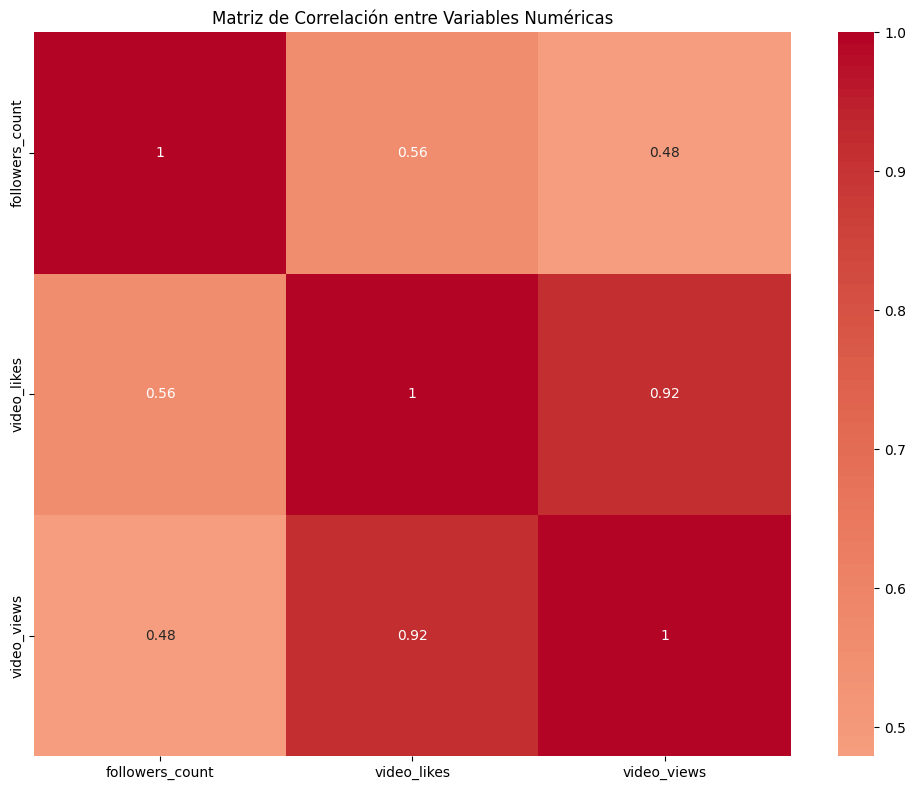


Analizando: followers_count
--------------------


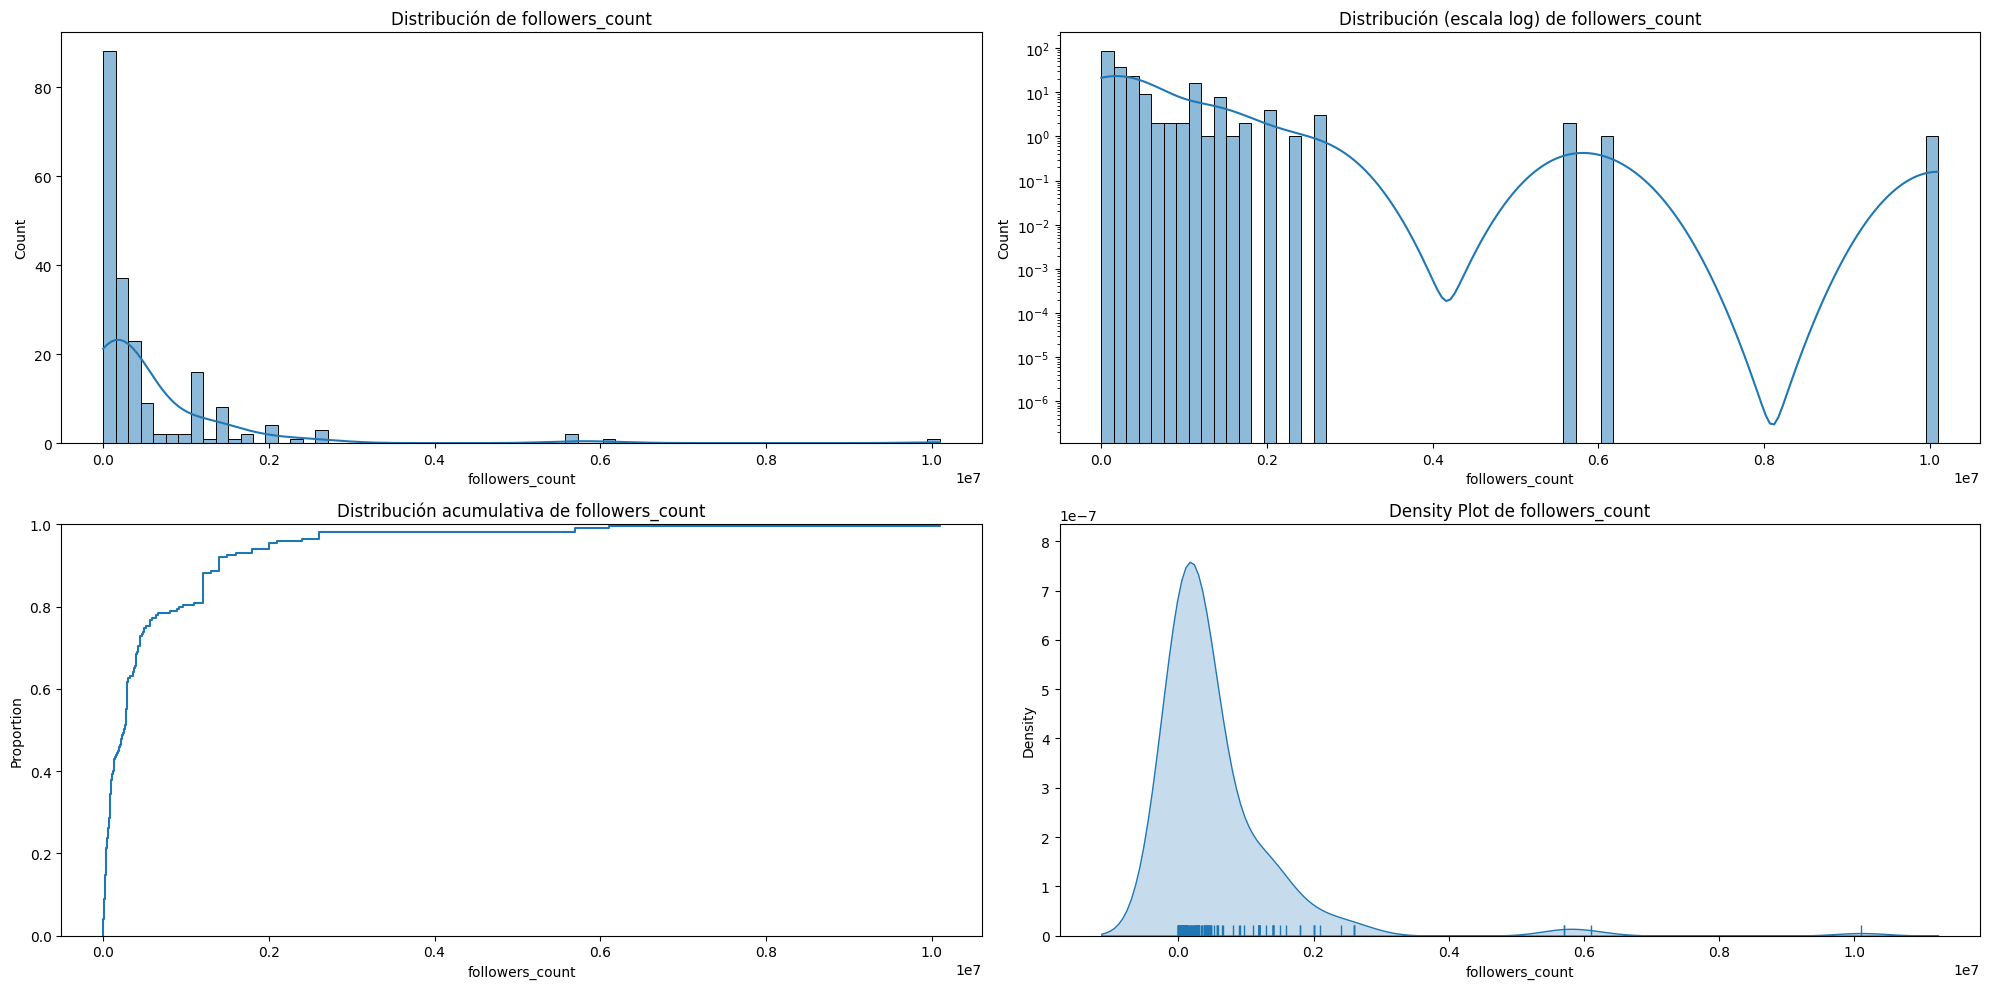


Estadísticas descriptivas:
count    2.030000e+02
mean     5.698519e+05
std      1.097576e+06
min      7.200000e+01
25%      6.060000e+04
50%      2.563990e+05
75%      5.058000e+05
max      1.010000e+07
Name: followers_count, dtype: float64

Métricas adicionales:
Asimetría (Skewness): 5.10
Curtosis: 34.45

Número de outliers detectados: 39

Analizando: video_likes
--------------------


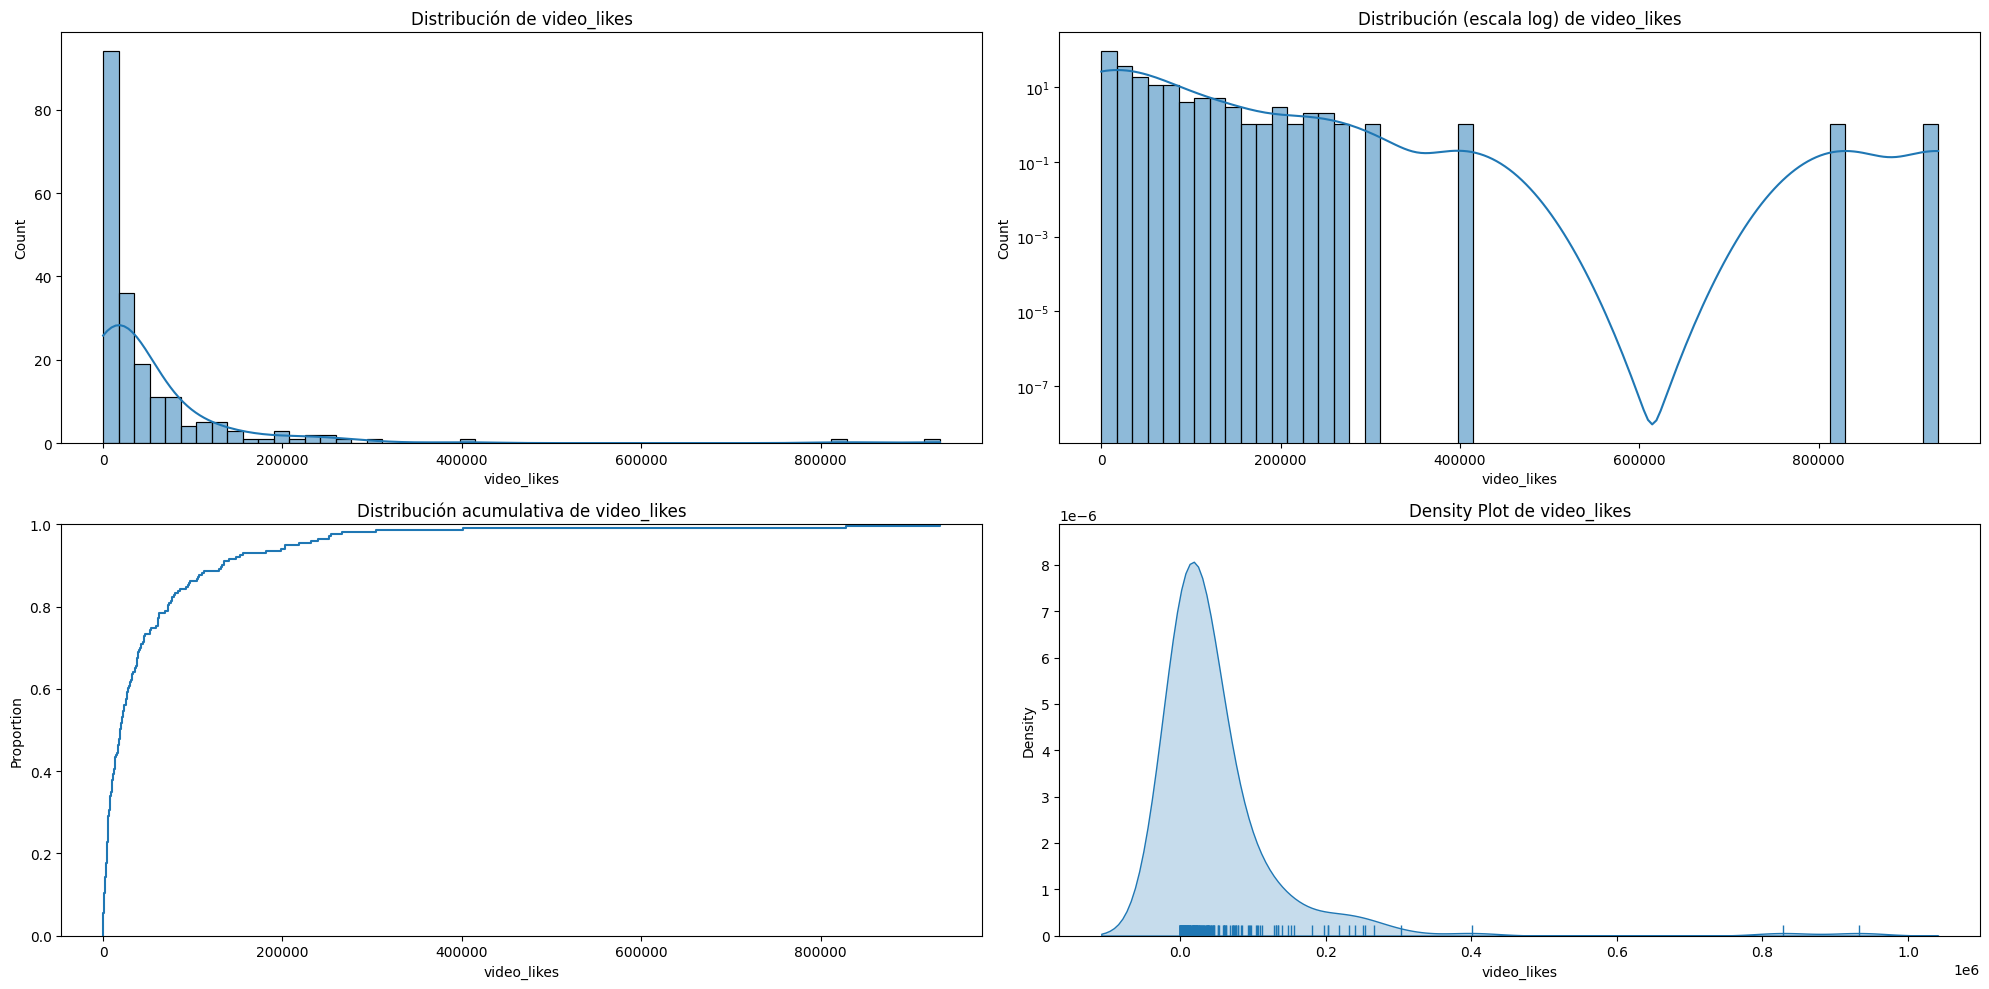


Estadísticas descriptivas:
count       203.000000
mean      52237.866995
std      104481.304023
min         111.000000
25%        5289.000000
50%       19100.000000
75%       56200.000000
max      933200.000000
Name: video_likes, dtype: float64

Métricas adicionales:
Asimetría (Skewness): 5.53
Curtosis: 39.53

Número de outliers detectados: 20

Analizando: video_views
--------------------


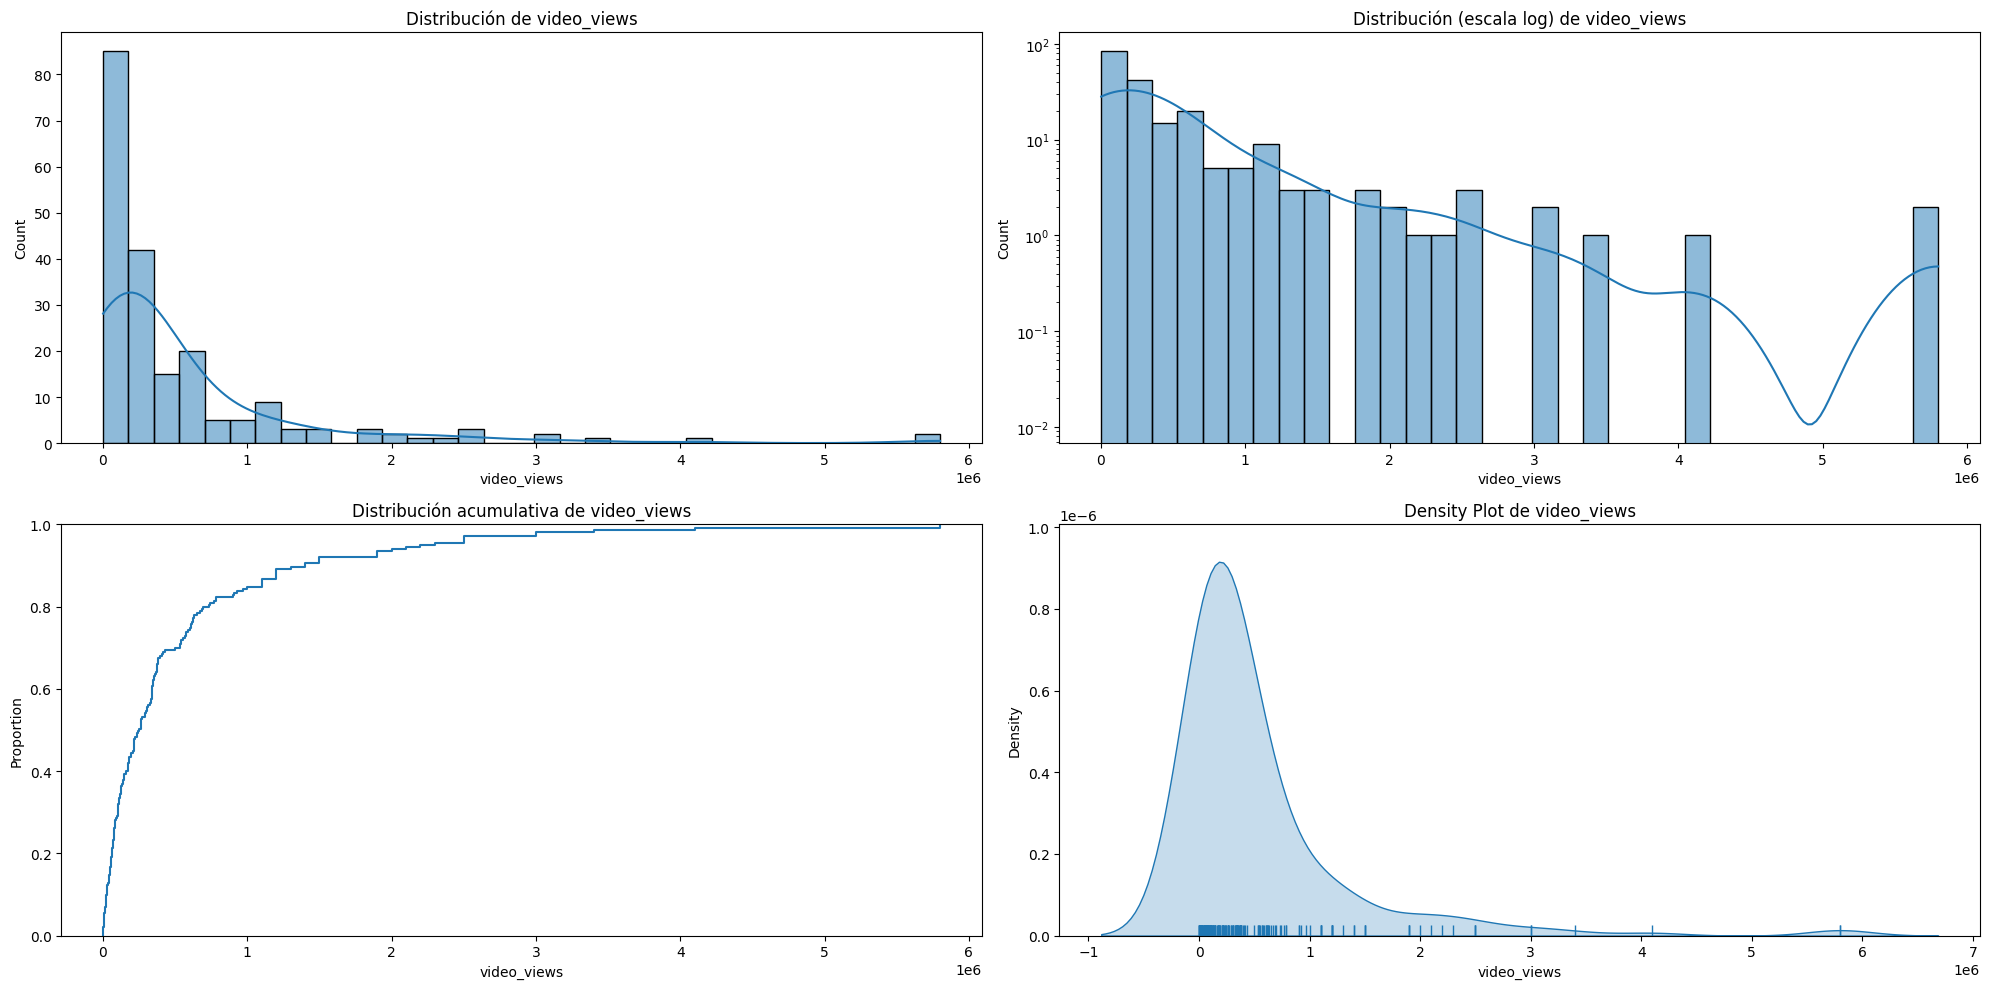


Estadísticas descriptivas:
count    2.030000e+02
mean     5.407222e+05
std      8.549202e+05
min      1.542000e+03
25%      7.895000e+04
50%      2.482000e+05
75%      6.051000e+05
max      5.800000e+06
Name: video_views, dtype: float64

Métricas adicionales:
Asimetría (Skewness): 3.46
Curtosis: 15.31

Número de outliers detectados: 21

📅 ANÁLISIS DE VARIABLES TEMPORALES
----------------------------------------

Analizando: publish_date
--------------------

Rango temporal:
Fecha más antigua: 2020-09-03 00:00:00
Fecha más reciente: 2025-01-28 00:00:00
Rango total en días: 1608


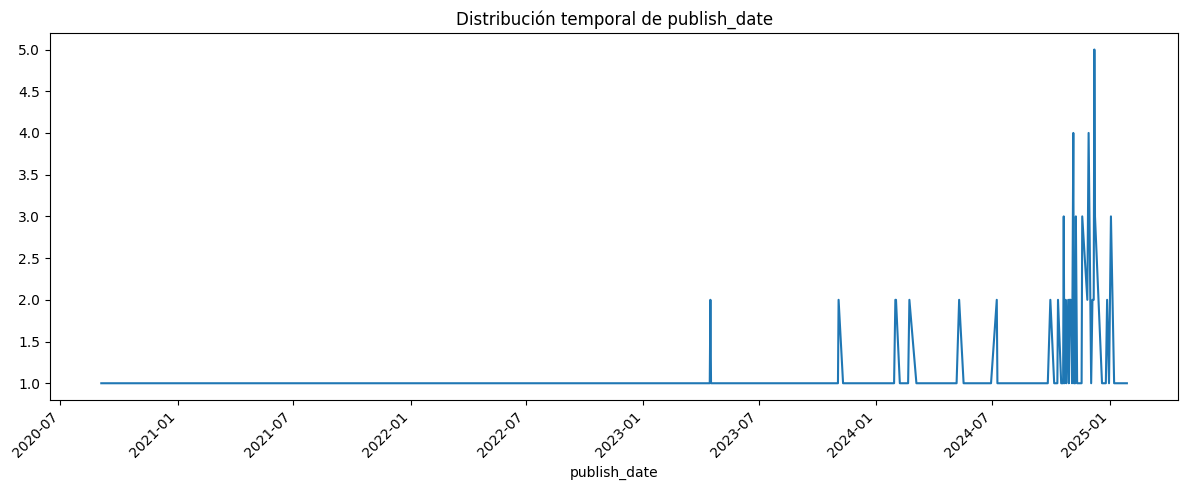


📝 ANÁLISIS DE VARIABLES DE TEXTO
----------------------------------------

Analizando: id_urlvideo
--------------------
Número de valores únicos: 203

Estadísticas de longitud del texto:
Longitud media: 61.59
Longitud mínima: 56
Longitud máxima: 70

Analizando: transcription
--------------------
Número de valores únicos: 203

Estadísticas de longitud del texto:
Longitud media: 3103.40
Longitud mínima: 43
Longitud máxima: 12429


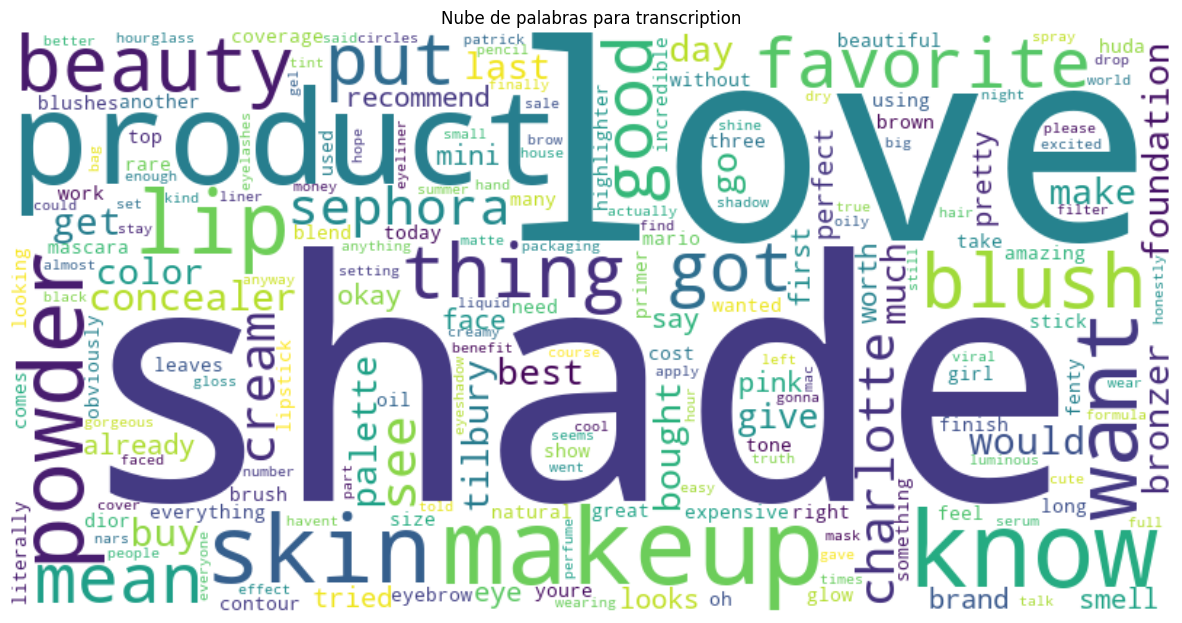


Top 20 palabras más frecuentes:
love: 585
shade: 573
makeup: 538
know: 524
skin: 428
beauty: 354
want: 349
blush: 348
put: 338
got: 314
good: 310
mean: 296
see: 294
products: 291
sephora: 289
product: 264
cream: 262
lip: 262
charlotte: 260
would: 256

Analizando: tiktok_username
--------------------
Número de valores únicos: 133

Estadísticas de longitud del texto:
Longitud media: 11.59
Longitud mínima: 6
Longitud máxima: 20

Analizando: video_description
--------------------
Número de valores únicos: 202

Estadísticas de longitud del texto:
Longitud media: 169.67
Longitud mínima: 2
Longitud máxima: 916


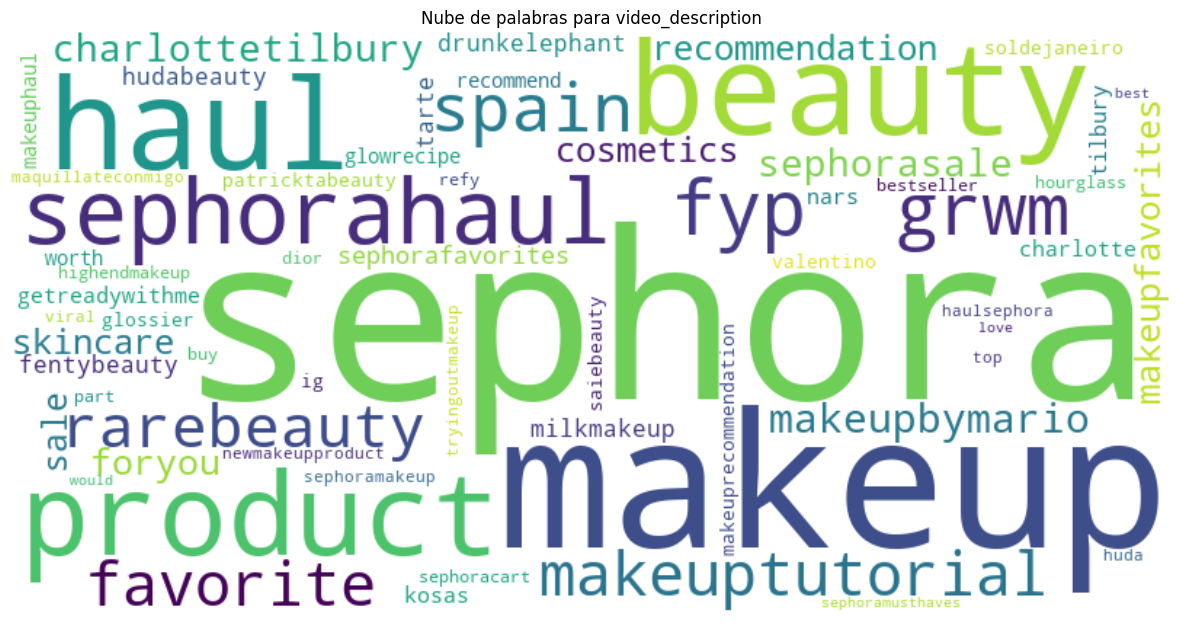


Top 20 palabras más frecuentes:
sephora: 216
makeup: 184
beauty: 68
haul: 61
products: 55
sephorahaul: 50
fyp: 38
grwm: 35
spain: 29
makeuptutorial: 23
rarebeauty: 23
makeupbymario: 23
charlottetilbury: 22
foryou: 21
sephorasale: 21
skincare: 20
makeupfavorites: 20
cosmetics: 20
recommendations: 19
sephorafavorites: 18


In [137]:
# Análisis Exploratorio-Descriptivo: 

def analizar_dataset(df):
    '''Analiza automáticamente todas las columnas del DataFrame según su tipo de dato.'''

    # STOPWORDS: español e inglés
    try:
        nltk.download('stopwords', quiet=True)
        stop_words_es = set(stopwords.words('spanish'))
        stop_words_en = set(stopwords.words('english'))

        # Palabras extra que quiero que elimine: 
        palabras_personalizadas = {
            'one', 'going', 'dont', 'really', 'also', 'super', 'use', 'little', 'well', 'ive', 'look', 'think', 'im', 'bit', 'seem', 'fisrt', 
            'okey', 'move', 'year', 'since', 'even', 'theres', 'quite', 'guy', 'time', 'come', 'cant', 'friend', 'every', 'dark', 'try', 'life', 'video', 
            'thats', 'ill', 'leave', 'ever', 'ones', 'doesnt', 'let', 'light', 'lot', 'start', 'never', 'tell', 'euro', 'nothing', 'always','end', 'called', 
            'theyre', 'way', 'circle', 'ta', 'fact', 'guys', 'didnt', 'next', 'seen', 'lets', 'new', 'years', 'euros', 'two', 'yes'}
        stop_words = stop_words_es.union(stop_words_en).union(palabras_personalizadas)
    except:
        print("Error descargando stopwords, usando lista básica")
        stop_words = {'de', 'la', 'el', 'en', 'y', 'a', 'que', 'the', 'of', 'to', 'and'}
    
    tipos_columnas = df.dtypes
    columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns
    columnas_fecha = df.select_dtypes(include=['datetime64']).columns
    columnas_texto = df.select_dtypes(include=['object', 'string']).columns
    
    # ANÁLISIS: Columnas Numéricas: 
    if len(columnas_numericas) > 0:
        print("\n📊 ANÁLISIS DE VARIABLES NUMÉRICAS")
        print("-"*40)
        
        # Matriz de Correlación para más de una variable numérica:
        if len(columnas_numericas) > 1:
            plt.figure(figsize=(10, 8))
            sns.heatmap(df[columnas_numericas].corr(), annot=True, cmap='coolwarm', center=0)
            plt.title('Matriz de Correlación entre Variables Numéricas')
            plt.tight_layout()
            plt.show()
        
        for columna in columnas_numericas:
            try:
                print(f"\nAnalizando: {columna}")
                print("-"*20)
                
                # Crear una figura con 4 subplots
                fig = plt.figure(figsize=(20, 10))
                
                # 1. Histograma con escala normal
                ax1 = plt.subplot(221)
                sns.histplot(data=df, x=columna, kde=True, ax=ax1)
                ax1.set_title(f'Distribución de {columna}')
                
                # 2. Histograma con escala logarítmica
                ax2 = plt.subplot(222)
                sns.histplot(data=df, x=columna, kde=True, ax=ax2)
                ax2.set_yscale('log')
                ax2.set_title(f'Distribución (escala log) de {columna}')
                
                # 3. ECDF (Empirical Cumulative Distribution)
                ax3 = plt.subplot(223)
                sns.ecdfplot(data=df, x=columna, ax=ax3)
                ax3.set_title(f'Distribución acumulativa de {columna}')
                
                # 4. Density Plot con rug plot
                ax4 = plt.subplot(224)
                sns.kdeplot(data=df[columna], fill=True, ax=ax4)
                sns.rugplot(data=df[columna], ax=ax4)
                ax4.set_title(f'Density Plot de {columna}')
                
                plt.tight_layout()
                plt.show()
                
                # Estadísticas descriptivas
                print("\nEstadísticas descriptivas:")
                stats = df[columna].describe()
                print(stats)
                
                # Métricas adicionales
                print("\nMétricas adicionales:")
                print(f"Asimetría (Skewness): {df[columna].skew():.2f}")
                print(f"Curtosis: {df[columna].kurtosis():.2f}")
                
                # Detectar outliers
                Q1 = stats['25%']
                Q3 = stats['75%']
                IQR = Q3 - Q1
                outliers = df[(df[columna] < (Q1 - 1.5 * IQR)) | (df[columna] > (Q3 + 1.5 * IQR))][columna]
                print(f"\nNúmero de outliers detectados: {len(outliers)}")
                
            except Exception as e:
                print(f"Error al analizar {columna}: {e}")
    
    # ANÁLISIS: Columnas Temporales: 
    if len(columnas_fecha) > 0:
        print("\n📅 ANÁLISIS DE VARIABLES TEMPORALES")
        print("-"*40)
        for columna in columnas_fecha:
            try:
                print(f"\nAnalizando: {columna}")
                print("-"*20)
                
                # Estadísticas temporales
                print("\nRango temporal:")
                print(f"Fecha más antigua: {df[columna].min()}")
                print(f"Fecha más reciente: {df[columna].max()}")
                print(f"Rango total en días: {(df[columna].max() - df[columna].min()).days}")
                
                # Distribución temporal
                plt.figure(figsize=(12, 5))
                df[columna].value_counts().sort_index().plot(kind='line')
                plt.title(f'Distribución temporal de {columna}')
                plt.xticks(rotation=45)
                plt.tight_layout()
                plt.show()
                
            except Exception as e:
                print(f"Error al analizar {columna}: {e}")
    
    # ANÁLISIS: Columnas de Texto: 
    if len(columnas_texto) > 0:
        print("\n📝 ANÁLISIS DE VARIABLES DE TEXTO")
        print("-"*40)
        for columna in columnas_texto:
            try:
                print(f"\nAnalizando: {columna}")
                print("-"*20)
                
                # Estadísticas básicas
                n_unique = df[columna].nunique()
                print(f"Número de valores únicos: {n_unique}")
                
                # Si hay menos de 20 valores únicos, mostrar distribución
                if n_unique < 20:
                    plt.figure(figsize=(10, 5))
                    df[columna].value_counts().plot(kind='bar')
                    plt.title(f'Distribución de {columna}')
                    plt.xticks(rotation=45)
                    plt.tight_layout()
                    plt.show()
                
                longitudes = df[columna].str.len()
                print("\nEstadísticas de longitud del texto:")
                print(f"Longitud media: {longitudes.mean():.2f}")
                print(f"Longitud mínima: {longitudes.min()}")
                print(f"Longitud máxima: {longitudes.max()}")
                
                # Columnas Username: hacer un ranking de frecuencia de aparición (influencers que más videos tienen)
                if columna == 'username':
                    value_counts = df[columna].value_counts()
                    print("\nTop 20 usernames más frecuentes:")
                    print(value_counts.head(20))
                
                # Emojis de la descripción: más basico (no muy relevante de momento)
                elif columna == 'description_emojis':
                    print("\nEmojis únicos encontrados:")
                    print(df[columna].unique())
                
                # Para las otras columnas de texto con más texto, hacer nubes de palabras: 
                elif columna in ['video_description', 'video_description_tags', 'transcription']:
                    texto_completo = ' '.join(df[columna].dropna().astype(str))
                    # Limpieza básica del texto:
                    texto_completo = texto_completo.lower()
                    texto_completo = re.sub(r'http\S+|www.\S+', '', texto_completo)
                    texto_completo = re.sub(r'[^\w\s]', '', texto_completo)
                    texto_completo = re.sub(r'\d+', '', texto_completo)

                    # NUBE con librería wordcloud: 
                    wordcloud = WordCloud(
                        width=800, 
                        height=400,
                        background_color='white',
                        stopwords=stop_words,
                        min_font_size=10,
                        collocations=False  # Evita que las palabras se repitan
                    ).generate(texto_completo)
                    
                    plt.figure(figsize=(15, 8))
                    plt.imshow(wordcloud, interpolation='bilinear')
                    plt.axis('off')
                    plt.title(f'Nube de palabras para {columna}')
                    plt.show()
                    
                    # Top palabras más frecuentes
                    words = [word for word in texto_completo.split() 
                            if word not in stop_words and len(word) > 2]
                    word_freq = Counter(words)
                    
                    print("\nTop 20 palabras más frecuentes:")
                    for word, freq in word_freq.most_common(20):
                        print(f"{word}: {freq}")
                
            except Exception as e:
                print(f"Error al analizar {columna}: {e}")

analizar_dataset(df)

In [141]:
nuevo_archivo = 'data/clean_data/url_data_cleaned.xlsx'
# Asegurarse de que el directorio clean_data existe
if not os.path.exists('data/clean_data'):
   os.makedirs('data/clean_data')
# Guardar
df.to_excel(nuevo_archivo, index=False)
print(f"Archivo guardado exitosamente en: {nuevo_archivo}")

Archivo guardado exitosamente en: data/clean_data/url_data_cleaned.xlsx
